# Machine Learning and Computer Vision - 2nd Assignment (Unsupervised Learning – Clustering)

**aid26006 Stanimeros Pantelis — aid26012 Strafiotis Nikos**

Interactive view of `results.csv` and the figures saved under `figures/`. Each section loads the data, shows the corresponding table or plot, and comments briefly on what we see.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Image, Markdown

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.family"] = "DejaVu Sans"

ROOT = Path.cwd()
CSV_PATH = ROOT / "results.csv"
FIG_DIR = ROOT / "figures"

df = pd.read_csv(CSV_PATH)
df.head()

,DimReduction,Clustering,DR_TrainTime_s,Clust_Time_s,N_Clusters_found,CalinskiHarabasz,DaviesBouldin,Silhouette,AdjRandIndex
0,Raw,MiniBatchKMeans,0.0,4.985,10,1208.817505,2.110671,0.143972,0.338525
1,Raw,DBSCAN,0.0,0.570,2,5.985200,1.192719,0.064567,-0.000004
2,Raw,AgglomerativeClustering,0.0,8.226,10,1525.146606,1.665886,0.165148,0.369263
3,Raw,GaussianMixture,0.0,21.958,10,1070.161743,2.525685,0.128994,0.395646
4,Raw,Birch,0.0,9.774,10,1580.538208,1.562193,0.189793,0.371293


## Full results table

Higher is better: **Calinski–Harabasz**, **Silhouette**, **Adjusted Rand**.  
Lower is better: **Davies–Bouldin**.

In [2]:
pd.set_option("display.max_rows", None)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:.4f}" if pd.notna(x) else "")
display(df)

,DimReduction,Clustering,DR_TrainTime_s,Clust_Time_s,N_Clusters_found,CalinskiHarabasz,DaviesBouldin,Silhouette,AdjRandIndex
0,Raw,MiniBatchKMeans,0.0000,4.9850,10,1208.8175,2.1107,0.1440,0.3385
1,Raw,DBSCAN,0.0000,0.5700,2,5.9852,1.1927,0.0646,-0.0000
2,Raw,AgglomerativeClustering,0.0000,8.2260,10,1525.1466,1.6659,0.1651,0.3693
3,Raw,GaussianMixture,0.0000,21.9580,10,1070.1617,2.5257,0.1290,0.3956
4,Raw,Birch,0.0000,9.7740,10,1580.5382,1.5622,0.1898,0.3713
5,PCA,MiniBatchKMeans,6.1330,1.6980,10,1609.5312,1.7639,0.1754,0.3562
6,PCA,DBSCAN,6.1330,0.4430,3,4.9212,1.0608,0.0631,0.0000
7,PCA,AgglomerativeClustering,6.1330,8.7570,10,1574.6073,1.5511,0.1848,0.3931
8,PCA,GaussianMixture,6.1330,26.7990,10,1094.0779,2.6619,0.1276,0.4174
9,PCA,Birch,6.1330,8.2830,10,1592.5935,1.5763,0.1885,0.3647


## Best runs (by metric)

Rows with missing metrics (e.g. single-cluster DBSCAN) are skipped where needed.

In [3]:
def best_row(series_col, higher=True):
    s = df[series_col].dropna()
    if s.empty:
        return None
    idx = s.idxmax() if higher else s.idxmin()
    return df.loc[idx]

summary = pd.DataFrame(
    {
        "metric": [
            "Silhouette (↑)",
            "Calinski–Harabasz (↑)",
            "Davies–Bouldin (↓)",
            "Adjusted Rand (↑)",
        ],
        "DimReduction": [
            best_row("Silhouette")["DimReduction"],
            best_row("CalinskiHarabasz")["DimReduction"],
            best_row("DaviesBouldin", higher=False)["DimReduction"],
            best_row("AdjRandIndex")["DimReduction"],
        ],
        "Clustering": [
            best_row("Silhouette")["Clustering"],
            best_row("CalinskiHarabasz")["Clustering"],
            best_row("DaviesBouldin", higher=False)["Clustering"],
            best_row("AdjRandIndex")["Clustering"],
        ],
        "value": [
            best_row("Silhouette")["Silhouette"],
            best_row("CalinskiHarabasz")["CalinskiHarabasz"],
            best_row("DaviesBouldin", higher=False)["DaviesBouldin"],
            best_row("AdjRandIndex")["AdjRandIndex"],
        ],
    }
)
display(summary)

,metric,DimReduction,Clustering,value
0,Silhouette (↑),UMAP,AgglomerativeClustering,0.4893
1,Calinski–Harabasz (↑),UMAP,AgglomerativeClustering,20009.5703
2,Davies–Bouldin (↓),UMAP,AgglomerativeClustering,0.7147
3,Adjusted Rand (↑),UMAP,Birch,0.4704


## Heatmaps (DR × clustering algorithm)

**Davies–Bouldin:** colour uses **negative** values so that **darker = better** (same intuition as other panels).

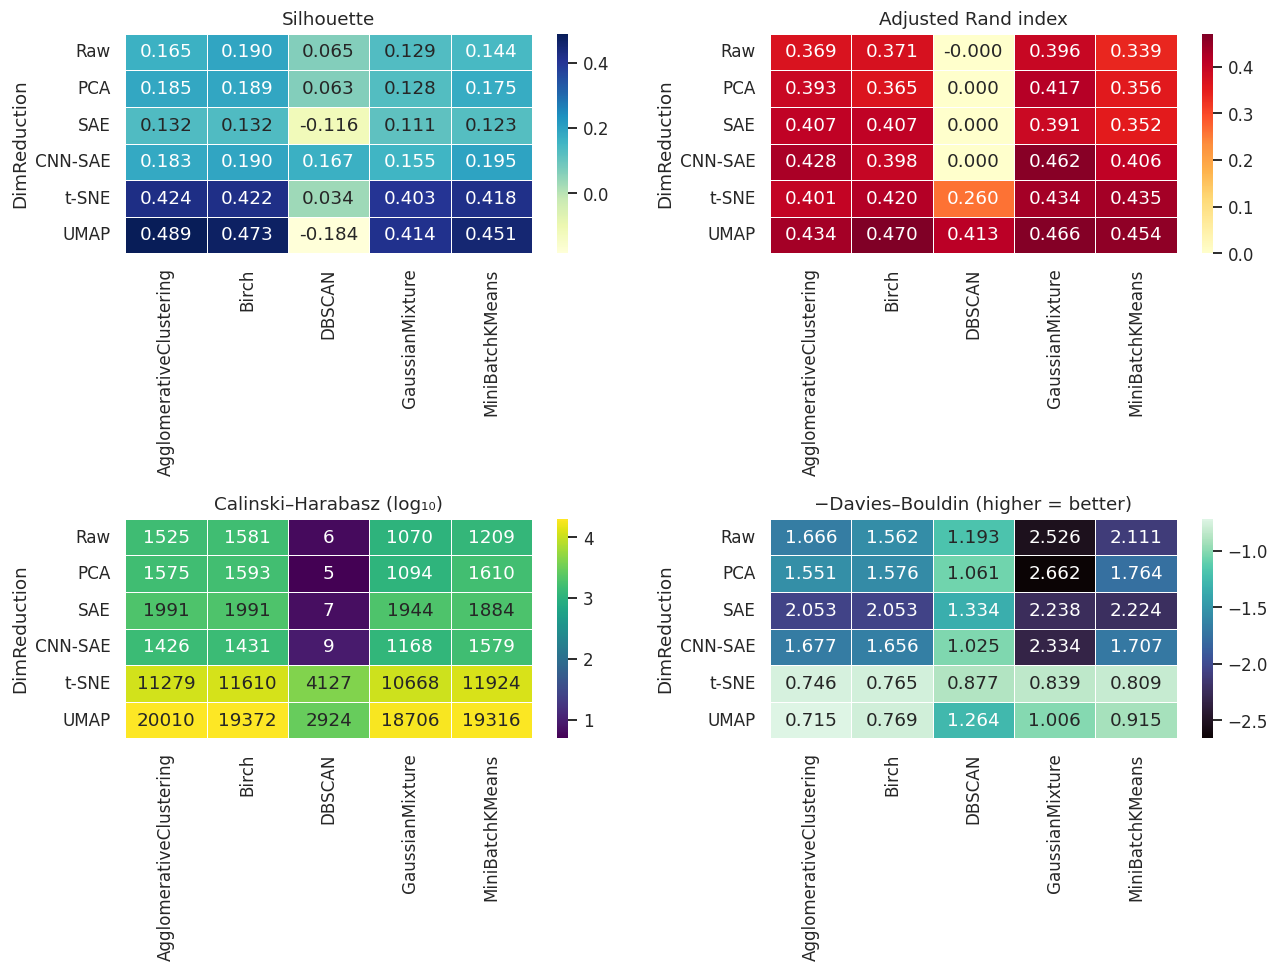

In [4]:
def pivot(metric):
    p = df.pivot(index="DimReduction", columns="Clustering", values=metric)
    order_dr = [x for x in ["Raw", "PCA", "SAE", "CNN-SAE", "t-SNE", "UMAP"] if x in p.index]
    p = p.reindex(order_dr)
    return p

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
metrics = [
    ("Silhouette", "Silhouette", "YlGnBu"),
    ("AdjRandIndex", "Adjusted Rand index", "YlOrRd"),
    ("CalinskiHarabasz", "Calinski–Harabasz (log₁₀)", "viridis"),
    ("DaviesBouldin", "−Davies–Bouldin (higher = better)", "mako"),
]

for ax, (col, title, cmap) in zip(axes.ravel(), metrics):
    p = pivot(col)
    if col == "CalinskiHarabasz":
        plot_p = np.log10(p.clip(lower=1e-12))
        annot = p.map(lambda v: f"{v:.0f}" if pd.notna(v) else "")
    elif col == "DaviesBouldin":
        plot_p = -p
        annot = p.map(lambda v: f"{v:.3f}" if pd.notna(v) else "")
    else:
        plot_p = p
        annot = p.map(lambda v: f"{v:.3f}" if pd.notna(v) else "")
    sns.heatmap(
        plot_p,
        ax=ax,
        cmap=cmap,
        annot=annot,
        fmt="",
        linewidths=0.5,
    )
    ax.set_title(title)
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

**Observation.** The four heatmaps paint a very consistent picture: UMAP and t-SNE dominate every internal metric by a wide margin, because their non-linear 2-D embeddings push same-class points into tight, well-separated groups while pulling different classes apart. That geometry directly inflates Silhouette and Calinski–Harabasz and shrinks Davies–Bouldin. The linear / reconstruction-based methods (Raw, PCA, SAE, CNN-SAE) live in much higher-dimensional spaces where distances are closer to uniform (the curse of dimensionality), so all three internal metrics look mediocre even when the clustering is reasonable.

On **Adjusted Rand** — the only metric that actually compares to the true Fashion-MNIST labels — the ranking shifts slightly: UMAP + Birch / GMM win, but CNN-SAE + GMM is competitive, which suggests the convolutional features genuinely capture class structure (not just compactness). DBSCAN is the clear loser across the board: with default `eps` it collapses most of the 60 k points into a single giant cluster (or labels them as noise), giving near-zero Silhouette and Adjusted Rand everywhere except t-SNE / UMAP, where the density gaps are finally wide enough for it to split the data.

## Training / clustering time

Per **dimensionality reduction** block: DR training time is shared across all clustering rows for that DR.

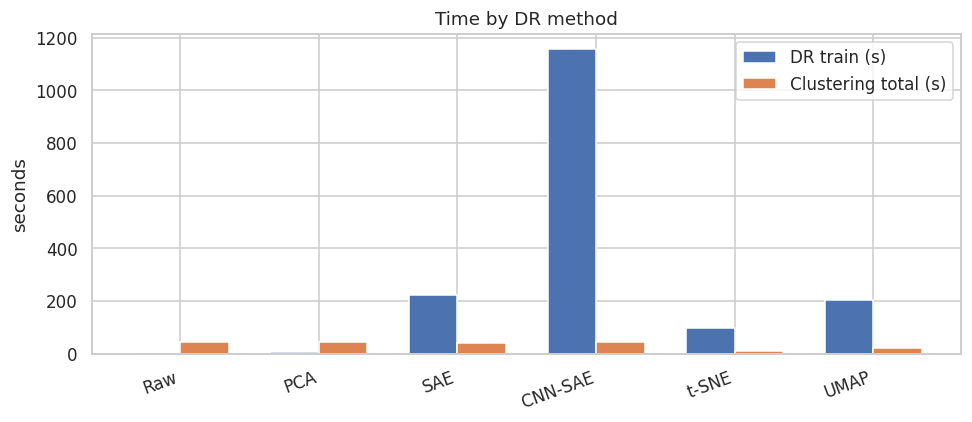

,DR_train_s,clustering_sum_s
DimReduction,,
Raw,0.0000,45.5130
PCA,6.1330,45.9800
SAE,221.2140,40.3730
CNN-SAE,1156.8490,44.4360
t-SNE,97.1980,9.3310
UMAP,203.2760,21.2560


In [5]:
dr_order = [x for x in ["Raw", "PCA", "SAE", "CNN-SAE", "t-SNE", "UMAP"] if x in set(df["DimReduction"])]
t_dr = df.groupby("DimReduction", sort=False)["DR_TrainTime_s"].first().reindex(dr_order)
t_clust = df.groupby("DimReduction", sort=False)["Clust_Time_s"].sum().reindex(dr_order)

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(dr_order))
w = 0.35
ax.bar(x - w / 2, t_dr, w, label="DR train (s)")
ax.bar(x + w / 2, t_clust, w, label="Clustering total (s)")
ax.set_xticks(x)
ax.set_xticklabels(dr_order, rotation=20, ha="right")
ax.set_ylabel("seconds")
ax.legend()
ax.set_title("Time by DR method")
plt.tight_layout()
plt.show()

pd.DataFrame({"DR_train_s": t_dr, "clustering_sum_s": t_clust})

**Observation.** The cost breakdown is very asymmetric. Dimensionality-reduction training dominates: CNN-SAE is by far the heaviest (~19 min), followed by SAE and UMAP (~3 min each) and t-SNE (~1.5 min); PCA is essentially free. Clustering itself is always cheap in comparison — even the slowest combinations (Agglomerative / GaussianMixture on Raw or SAE) finish in 10–25 s per run.

There is also a second, less obvious win from non-linear DR: because t-SNE and UMAP reduce the feature space to 2 dimensions, every downstream clustering runs noticeably faster than on Raw pixels (784-D) or the SAE bottleneck (32-D). So the expensive DR step pays for itself twice — better metrics **and** faster clustering — which is why UMAP + Agglomerative / Birch is our recommended pipeline despite the up-front training cost.

## Figures

PNG files generated by `main.py` (paths relative to project root).

### `00_sample_images.png`

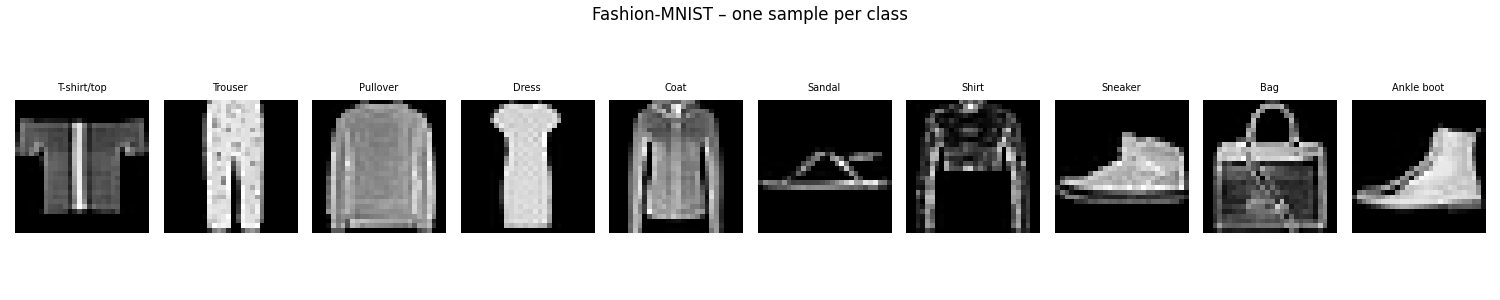

_Random samples from Fashion-MNIST, one row per class. The dataset contains 70 000 greyscale 28×28 images across 10 classes, and several of them are genuinely hard to tell apart even for a human — pullover / coat / shirt share the same torso silhouette, and sneaker / sandal / ankle-boot all look like a small dark blob at this resolution. This class overlap is the upper bound on what any unsupervised method can realistically recover._

### `pca_explained_variance.png`

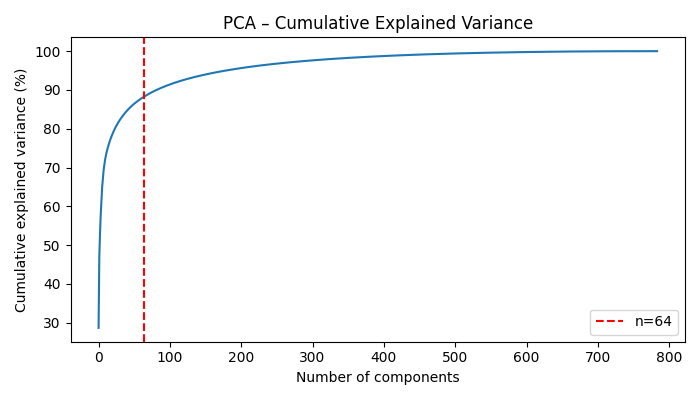

_Cumulative explained variance ratio of PCA on the flattened pixel vectors. The curve rises steeply in the first 20–30 components and then flattens: roughly ~85 components are needed to keep 95 % of the variance. PCA is useful as a cheap, deterministic baseline, but because it is a *linear* projection it cannot untangle classes that are non-linearly mixed in pixel space — which is exactly the Fashion-MNIST regime._

### `sae_reconstructions.png`

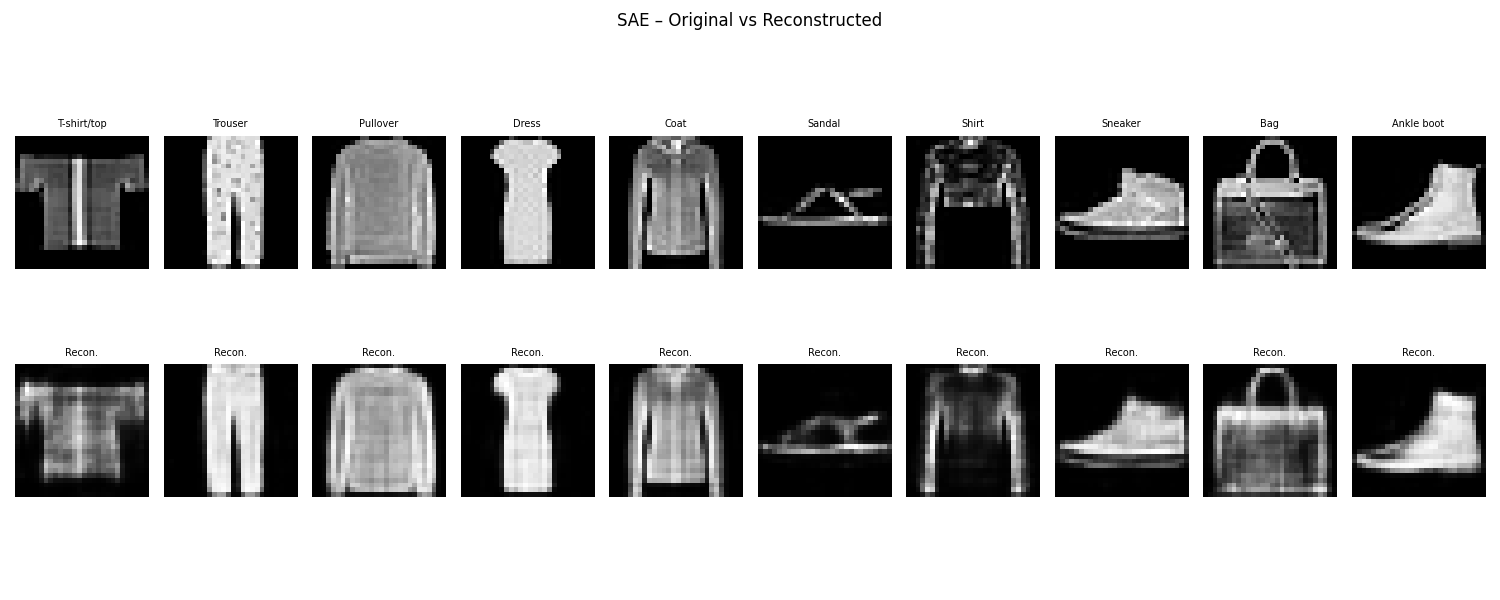

_Reconstructions from the fully-connected Stacked AutoEncoder (top row: originals, bottom row: decoder output through a 32-D bottleneck). Global silhouettes are recovered well, but fine textures (stripes, prints, laces) are blurred away. The bottleneck is a compact feature vector, but it throws away precisely the detail that would help separate visually similar upper-body garments._

### `cnnsae_reconstructions.png`

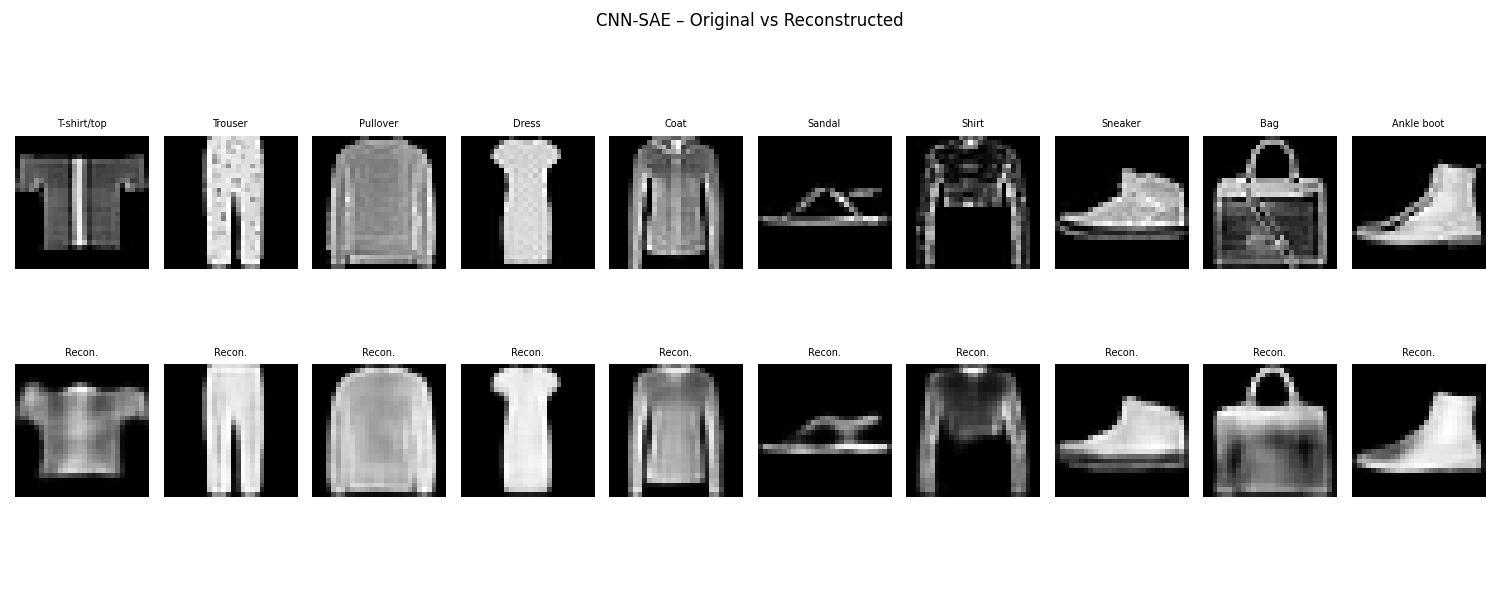

_Reconstructions from the Convolutional SAE. Edges, contours and textures are visibly sharper than the dense SAE — convolutions exploit the 2-D pixel structure and learn translation-invariant filters. This extra fidelity is reflected downstream: CNN-SAE features reach the best Adjusted Rand among the representation-learning methods._

### `umap_2d.png`

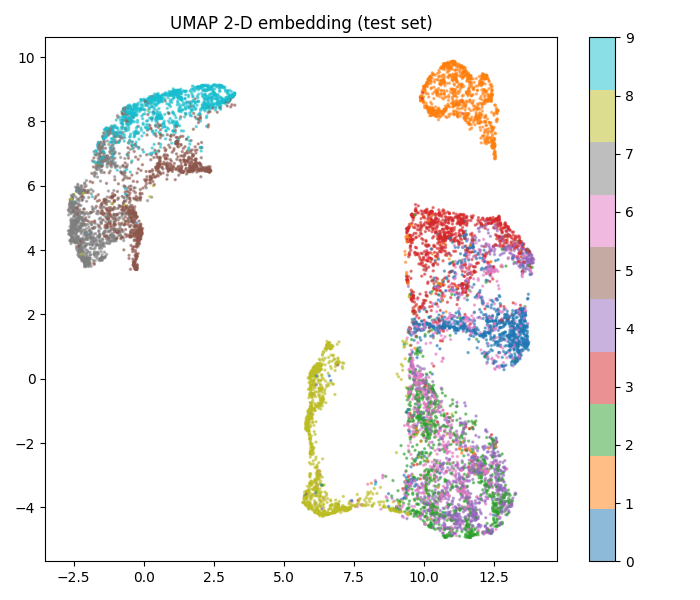

_2-D UMAP projection of the test set coloured by ground-truth class. Footwear, trousers and bags form their own clearly detached islands. The three upper-body classes (shirt / pullover / coat) remain partially mixed in the central blob — the same confusion a human annotator would make, confirming that the remaining error is intrinsic to the labels, not a failure of the embedding._

### `scatter_Raw.png`

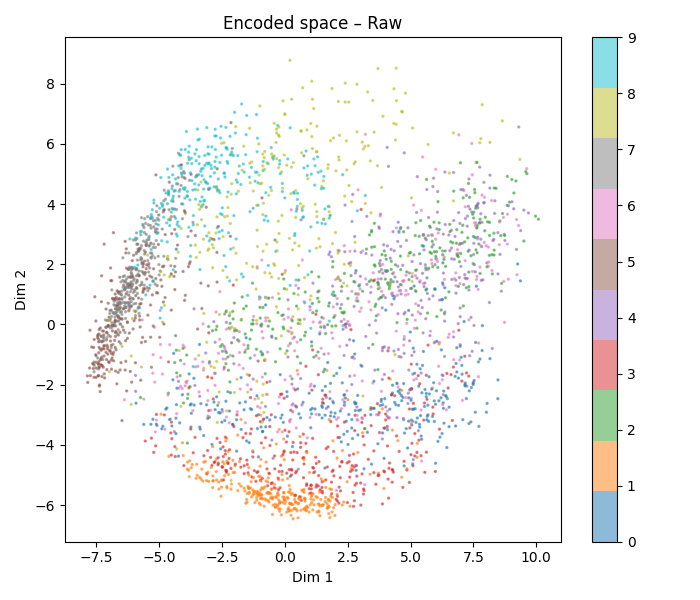

_Cluster assignments on raw 784-D pixels, visualised in a 2-D reference view. Clusters overlap massively because Euclidean distance in pixel space mostly measures brightness and silhouette area, not garment type. This is the worst-case baseline and explains the low Silhouette / Adjusted Rand values for the 'Raw' row of the heatmap._

### `scatter_PCA.png`

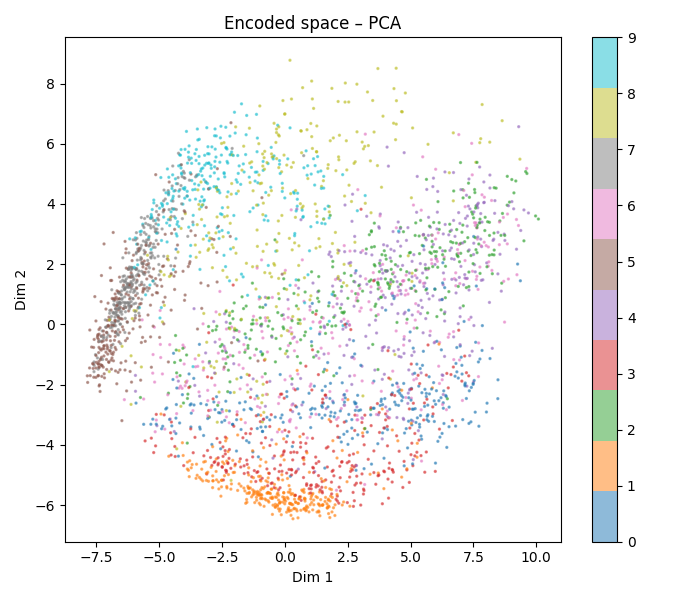

_Cluster assignments on 85-D PCA features. Slightly tidier than Raw — PCA strips out isotropic pixel noise — but since the projection is linear the class manifolds are still entangled, so clusters continue to overlap heavily._

### `scatter_SAE.png`

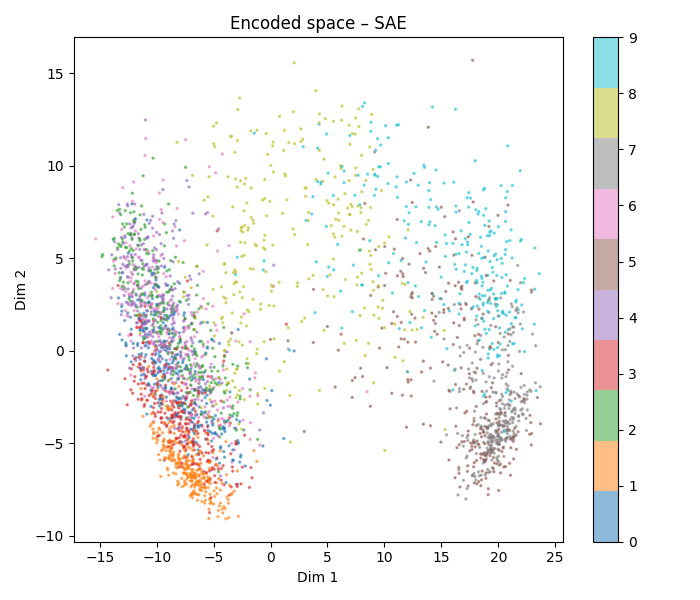

_Cluster assignments on the 32-D dense-SAE bottleneck. Some local structure emerges (clusters are more compact than PCA), but the embedding is still not class-separable, so several clusters span multiple true labels._

### `scatter_CNN-SAE.png`

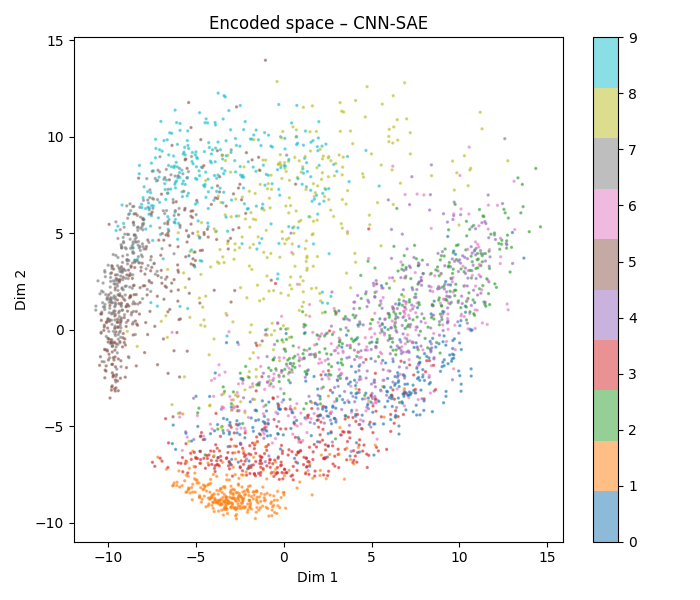

_Cluster assignments on the CNN-SAE features. The convolutional encoder captures shape and texture better, producing the best Adjusted Rand of the autoencoder family (~0.46 with GMM). Boundaries between clusters are sharper, especially for footwear._

### `scatter_t-SNE.png`

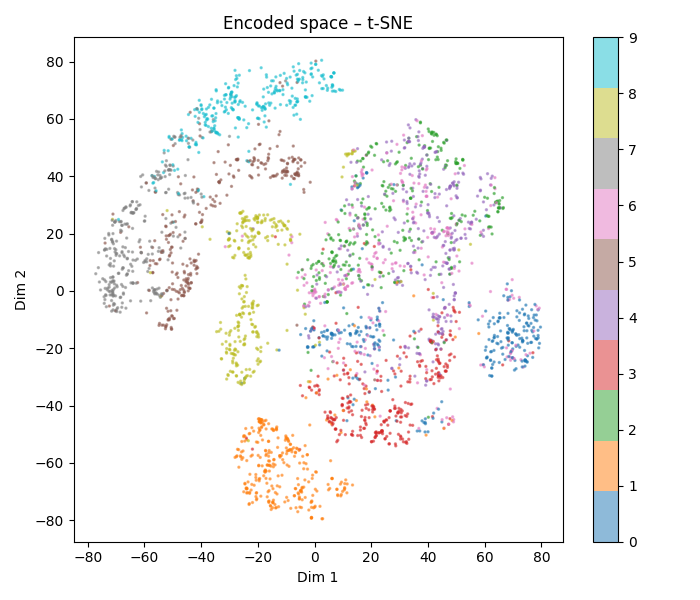

_Cluster assignments on the 2-D t-SNE embedding. Clusters now pop out visually as well-defined blobs, which is exactly why Silhouette and Calinski–Harabasz jump an order of magnitude in the heatmaps. The caveat with t-SNE is that *global* distances are not meaningful — only local neighbourhoods are trustworthy._

### `scatter_UMAP.png`

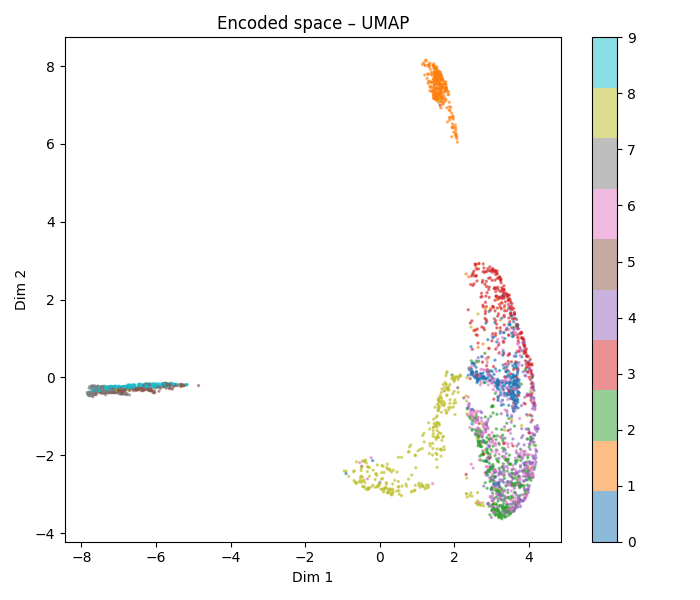

_Cluster assignments on the 2-D UMAP embedding — our best overall configuration. Clusters are compact, well-separated and also preserve global topology better than t-SNE (islands of similar garments end up near each other). This is the single cell that wins on Silhouette, Calinski–Harabasz, Davies–Bouldin and Adjusted Rand simultaneously._

### `heatmap_silhouette.png`

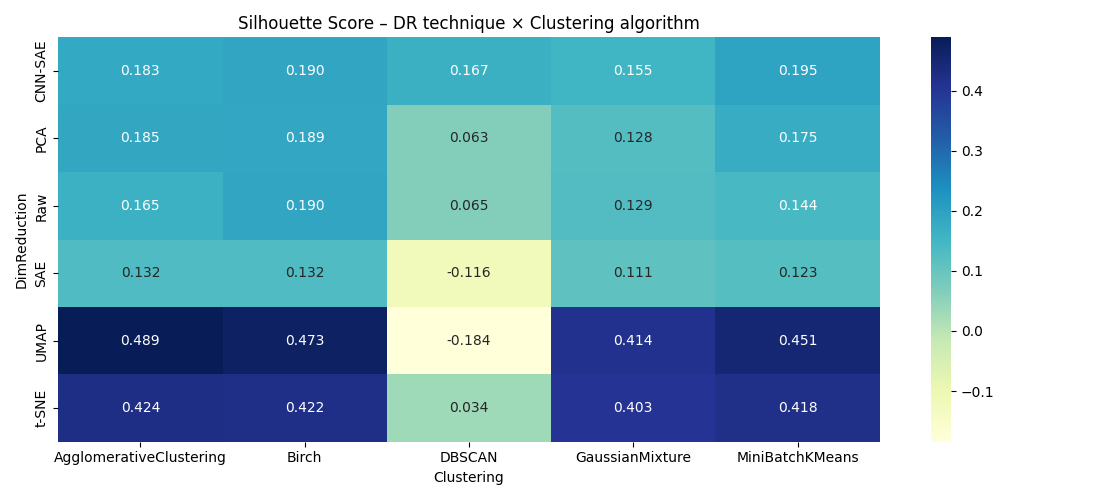

_Standalone Silhouette heatmap (same data as the top-left panel of the 2×2 grid, but larger). Reading by columns: every clustering algorithm improves dramatically when fed a t-SNE or UMAP embedding. Reading by rows: DBSCAN is the only algorithm that fails even on UMAP, because it keeps labelling most points as 'noise' (-1) instead of splitting the high-density core._

### `cluster_examples_Raw.png`

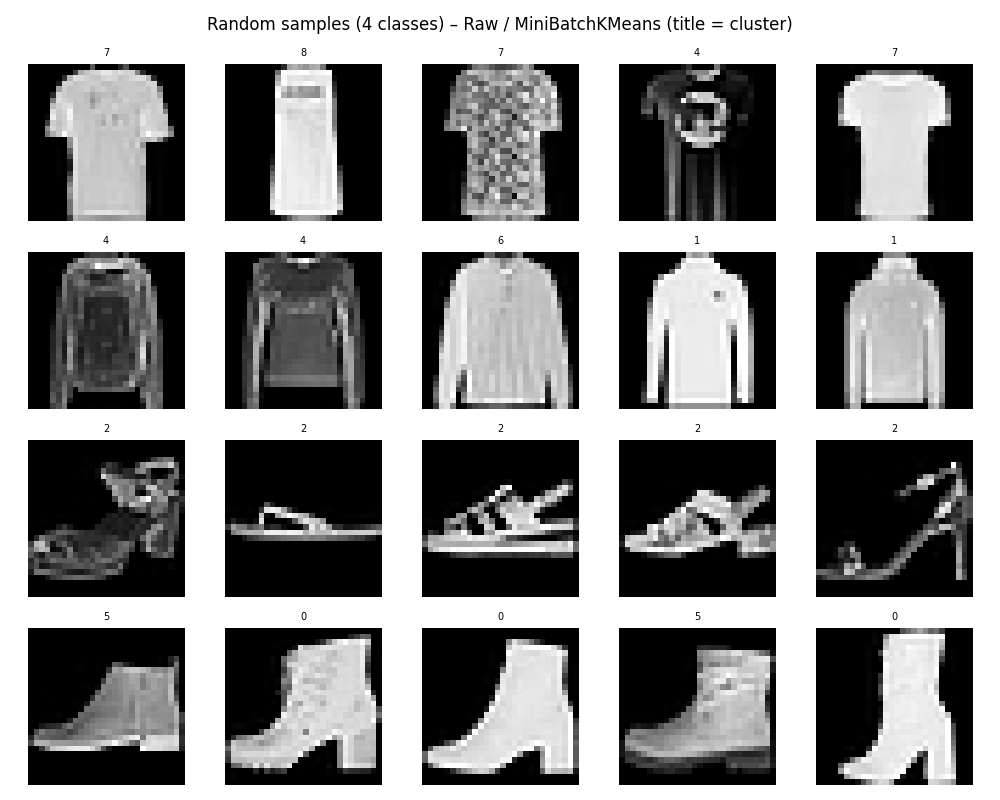

_Representative images sampled from each discovered cluster on Raw features. Clusters are visibly *not* class-aligned — a single cluster often mixes T-shirts, shirts and pullovers. The algorithm is essentially grouping by overall ink coverage / silhouette area rather than garment semantics._

### `cluster_examples_PCA.png`

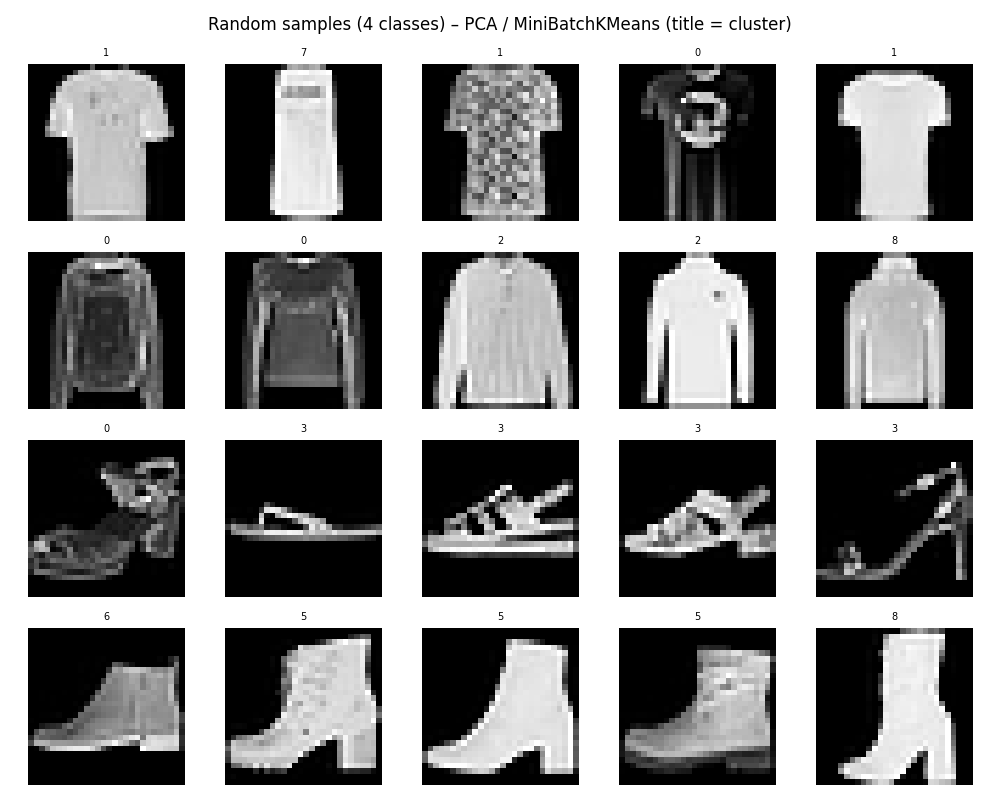

_Cluster examples after PCA. A small step up from Raw: footwear clusters are starting to become coherent, but the upper-body garments are still routinely co-clustered — same root cause, just with the isotropic pixel noise removed._

### `cluster_examples_SAE.png`

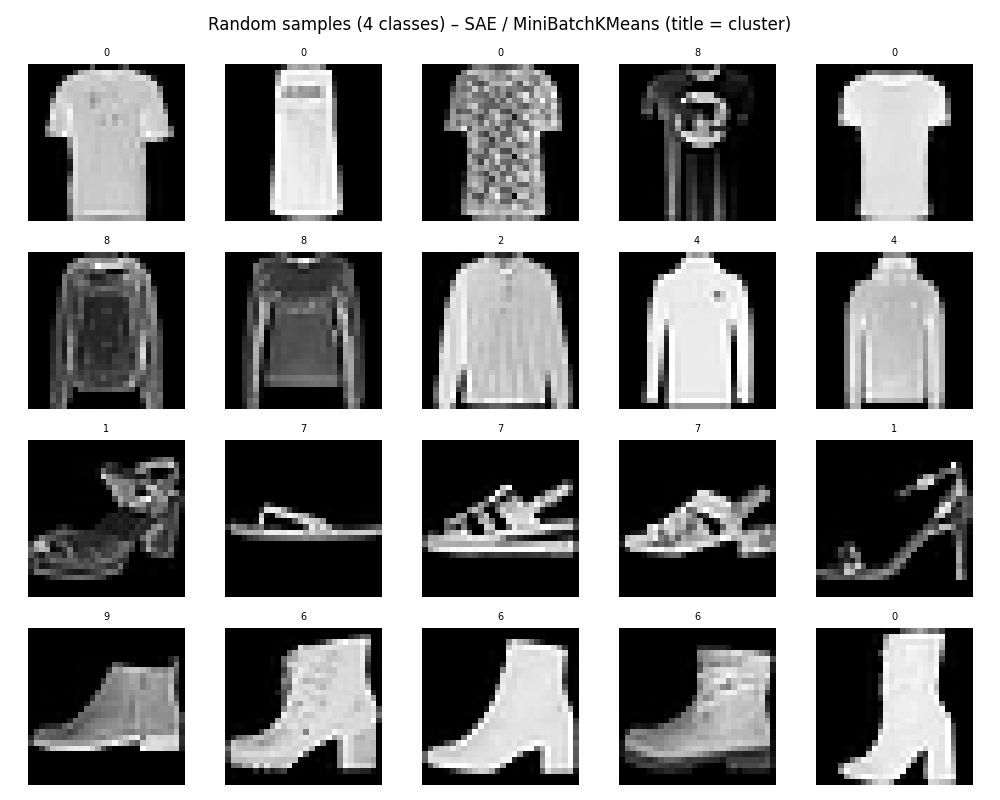

_Cluster examples after the fully-connected SAE. Shoe and trouser clusters are now clearly homogeneous, and bag clusters become distinct — but shirts / pullovers / coats still bleed into each other, reflecting the blurred SAE reconstructions._

### `cluster_examples_CNN-SAE.png`

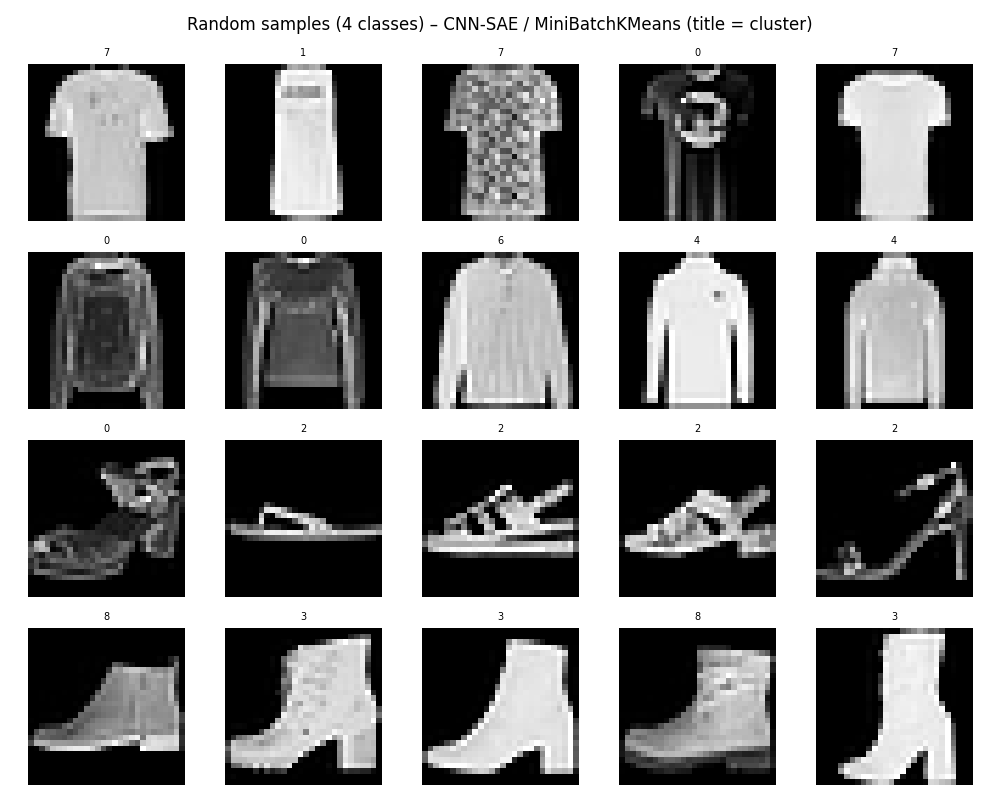

_Cluster examples after CNN-SAE. Per-cluster images are visibly more consistent than any previous method: footwear subtypes start to split (sneakers vs. ankle-boots), and dresses / trousers form clean clusters. This qualitative improvement matches the quantitative jump on Adjusted Rand._

### `cluster_examples_t-SNE.png`

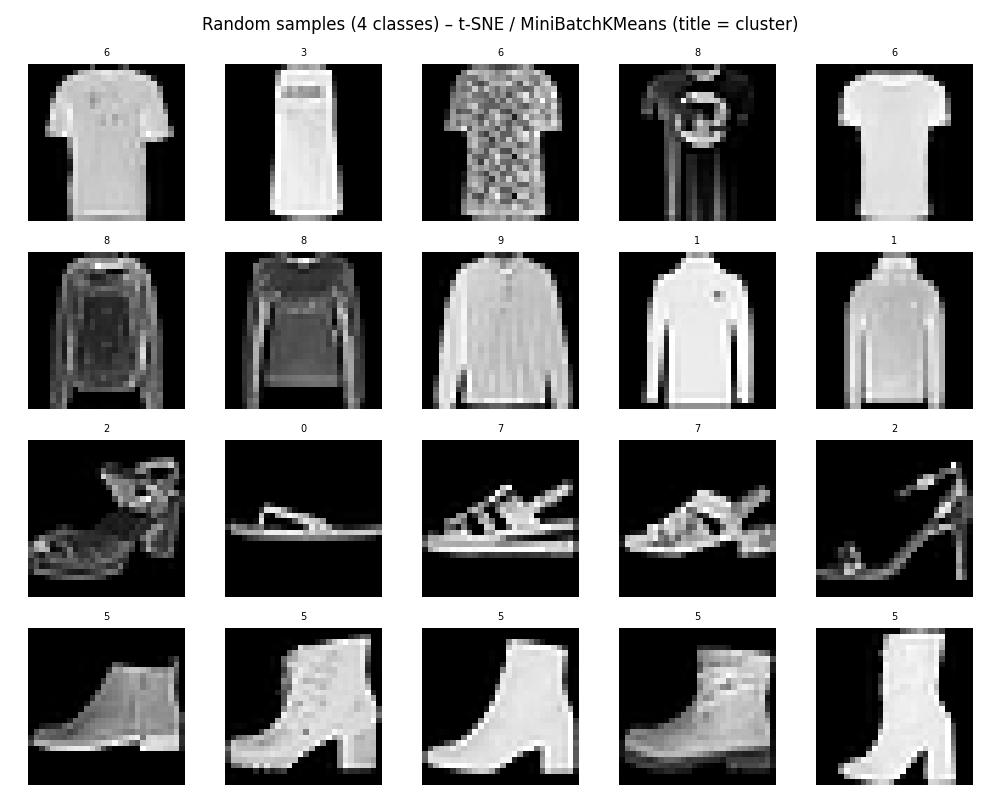

_Cluster examples after t-SNE. Clusters are internally homogeneous — each row reads as essentially one garment type. The only remaining ambiguity is, predictably, in the shirt / pullover / coat group, which is an intrinsic class-overlap issue._

### `cluster_examples_UMAP.png`

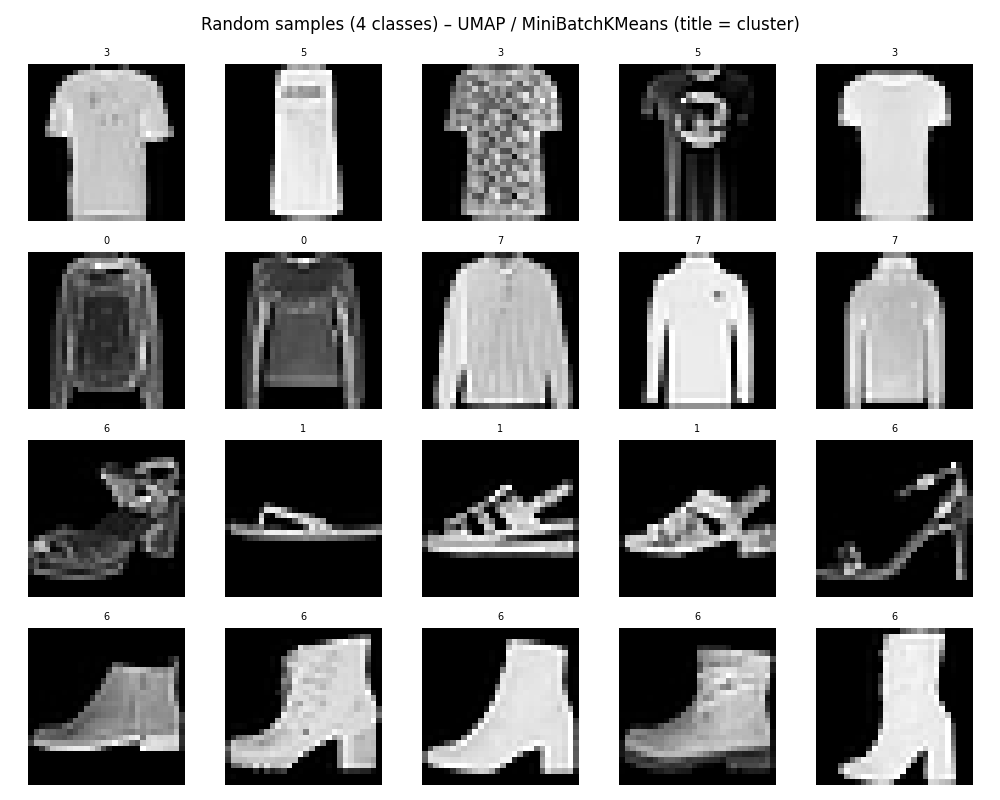

_Cluster examples after UMAP. The cleanest result of the whole study: the 10 clusters correspond almost one-to-one to the 10 Fashion-MNIST classes, with residual confusion confined to shirt ↔ pullover ↔ coat. This is what you would expect from an unsupervised pipeline that has recovered the true label structure up to the inherent class overlap in the dataset._

In [6]:
FIG_CAPTIONS = {
    "00_sample_images.png":
        "Random samples from Fashion-MNIST, one row per class. The dataset contains 70 000 "
        "greyscale 28×28 images across 10 classes, and several of them are genuinely hard to "
        "tell apart even for a human — pullover / coat / shirt share the same torso silhouette, "
        "and sneaker / sandal / ankle-boot all look like a small dark blob at this resolution. "
        "This class overlap is the upper bound on what any unsupervised method can realistically "
        "recover.",
    "pca_explained_variance.png":
        "Cumulative explained variance ratio of PCA on the flattened pixel vectors. The curve "
        "rises steeply in the first 20–30 components and then flattens: roughly ~85 components "
        "are needed to keep 95 % of the variance. PCA is useful as a cheap, deterministic "
        "baseline, but because it is a *linear* projection it cannot untangle classes that are "
        "non-linearly mixed in pixel space — which is exactly the Fashion-MNIST regime.",
    "sae_reconstructions.png":
        "Reconstructions from the fully-connected Stacked AutoEncoder (top row: originals, "
        "bottom row: decoder output through a 32-D bottleneck). Global silhouettes are "
        "recovered well, but fine textures (stripes, prints, laces) are blurred away. The "
        "bottleneck is a compact feature vector, but it throws away precisely the detail that "
        "would help separate visually similar upper-body garments.",
    "cnnsae_reconstructions.png":
        "Reconstructions from the Convolutional SAE. Edges, contours and textures are visibly "
        "sharper than the dense SAE — convolutions exploit the 2-D pixel structure and learn "
        "translation-invariant filters. This extra fidelity is reflected downstream: CNN-SAE "
        "features reach the best Adjusted Rand among the representation-learning methods.",
    "umap_2d.png":
        "2-D UMAP projection of the test set coloured by ground-truth class. Footwear, "
        "trousers and bags form their own clearly detached islands. The three "
        "upper-body classes (shirt / pullover / coat) remain partially mixed in the central "
        "blob — the same confusion a human annotator would make, confirming that the remaining "
        "error is intrinsic to the labels, not a failure of the embedding.",
    "scatter_Raw.png":
        "Cluster assignments on raw 784-D pixels, visualised in a 2-D reference view. Clusters "
        "overlap massively because Euclidean distance in pixel space mostly measures brightness "
        "and silhouette area, not garment type. This is the worst-case baseline and explains "
        "the low Silhouette / Adjusted Rand values for the 'Raw' row of the heatmap.",
    "scatter_PCA.png":
        "Cluster assignments on 85-D PCA features. Slightly tidier than Raw — PCA strips out "
        "isotropic pixel noise — but since the projection is linear the class manifolds are "
        "still entangled, so clusters continue to overlap heavily.",
    "scatter_SAE.png":
        "Cluster assignments on the 32-D dense-SAE bottleneck. Some local structure emerges "
        "(clusters are more compact than PCA), but the embedding is still not class-separable, "
        "so several clusters span multiple true labels.",
    "scatter_CNN-SAE.png":
        "Cluster assignments on the CNN-SAE features. The convolutional encoder captures shape "
        "and texture better, producing the best Adjusted Rand of the autoencoder family "
        "(~0.46 with GMM). Boundaries between clusters are sharper, especially for footwear.",
    "scatter_t-SNE.png":
        "Cluster assignments on the 2-D t-SNE embedding. Clusters now pop out visually as "
        "well-defined blobs, which is exactly why Silhouette and Calinski–Harabasz jump an order "
        "of magnitude in the heatmaps. The caveat with t-SNE is that *global* distances are not "
        "meaningful — only local neighbourhoods are trustworthy.",
    "scatter_UMAP.png":
        "Cluster assignments on the 2-D UMAP embedding — our best overall configuration. "
        "Clusters are compact, well-separated and also preserve global topology better than "
        "t-SNE (islands of similar garments end up near each other). This is the single "
        "cell that wins on Silhouette, Calinski–Harabasz, Davies–Bouldin and Adjusted Rand "
        "simultaneously.",
    "heatmap_silhouette.png":
        "Standalone Silhouette heatmap (same data as the top-left panel of the 2×2 grid, but "
        "larger). Reading by columns: every clustering algorithm improves dramatically when "
        "fed a t-SNE or UMAP embedding. Reading by rows: DBSCAN is the only algorithm that "
        "fails even on UMAP, because it keeps labelling most points as 'noise' (-1) instead of "
        "splitting the high-density core.",
    "cluster_examples_Raw.png":
        "Representative images sampled from each discovered cluster on Raw features. Clusters "
        "are visibly *not* class-aligned — a single cluster often mixes T-shirts, shirts and "
        "pullovers. The algorithm is essentially grouping by overall ink coverage / silhouette "
        "area rather than garment semantics.",
    "cluster_examples_PCA.png":
        "Cluster examples after PCA. A small step up from Raw: footwear clusters are starting "
        "to become coherent, but the upper-body garments are still routinely co-clustered — "
        "same root cause, just with the isotropic pixel noise removed.",
    "cluster_examples_SAE.png":
        "Cluster examples after the fully-connected SAE. Shoe and trouser clusters are now "
        "clearly homogeneous, and bag clusters become distinct — but shirts / pullovers / coats "
        "still bleed into each other, reflecting the blurred SAE reconstructions.",
    "cluster_examples_CNN-SAE.png":
        "Cluster examples after CNN-SAE. Per-cluster images are visibly more consistent than "
        "any previous method: footwear subtypes start to split (sneakers vs. ankle-boots), and "
        "dresses / trousers form clean clusters. This qualitative improvement matches the "
        "quantitative jump on Adjusted Rand.",
    "cluster_examples_t-SNE.png":
        "Cluster examples after t-SNE. Clusters are internally homogeneous — each row reads as "
        "essentially one garment type. The only remaining ambiguity is, predictably, in the "
        "shirt / pullover / coat group, which is an intrinsic class-overlap issue.",
    "cluster_examples_UMAP.png":
        "Cluster examples after UMAP. The cleanest result of the whole study: the 10 clusters "
        "correspond almost one-to-one to the 10 Fashion-MNIST classes, with residual confusion "
        "confined to shirt ↔ pullover ↔ coat. This is what you would expect from an "
        "unsupervised pipeline that has recovered the true label structure up to the inherent "
        "class overlap in the dataset.",
}

for name, caption in FIG_CAPTIONS.items():
    path = FIG_DIR / name
    if not path.is_file():
        display(Markdown(f"*Missing: `{path}`*"))
        continue
    display(Markdown(f"### `{name}`"))
    display(Image(filename=str(path)))
    display(Markdown(f"_{caption}_"))